In [8]:
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

filename = '/home/lacrio/Documents/thermo_eq_test/data/era5_t_uvw_20200204_20200216_dmean.nc'
nc = netCDF4.Dataset(filename)
print(nc)

#Get dimensions
lons = nc.variables['longitude'][:]
lats = nc.variables['latitude'][:]
times = nc.variables['valid_time'][:]

#Weighting grid
lons_sec_grid, lats_sec_grid = np.meshgrid(lons, lats)
weighting_grid = np.sqrt(np.cos(lats_sec_grid*np.pi/180))

print(lons)
print(lats)

#Calculate datetime
dtimes = np.empty(len(times), dtype='datetime64[s]')

for i, t in enumerate(times):
    dtimes[i] = np.datetime64('1970-01-01') + np.timedelta64(int(t), 's')

dtimes = dtimes.astype('datetime64')
print(dtimes)
#0 = 850, 1 = 750, 2 = 700
#Get variables
T900 = nc.variables['t'][:,0,:,:]-273.15
T950 = nc.variables['t'][:,1,:,:]-273.15
T925 = nc.variables['t'][:,2,:,:]-273.15
w925 = nc.variables['w'][:,2,:,:]
U925 = nc.variables['u'][:,2,:,:]
V925 = nc.variables['v'][:,2,:,:]

##Calculate daily advection##
#Calculate distances of the grid points in m
lons_g, lats_g = np.meshgrid(lons,lats)
Xdist_arr = np.diff(lons_g * np.pi * 6371000 / 180) * np.cos(lats_g[:,:-1] * np.pi / 180) #distance between Xs
Ydist_arr = np.diff(lats_g, axis=0) * np.pi * 6371000 / 180 #distance between Ys

#Advection in horizontal axis
dT_dx = (np.diff(T925, axis=2)[:,:,:-1] + np.diff(T925, axis=2)[:,:,1:]) / 2 / (2*Xdist_arr[:,:-1])
dT_dy = (np.diff(T925, axis=1)[:,:-1,:] + np.diff(T925, axis=1)[:,1:,:]) / 2 / (2*Ydist_arr[:-1,:])
Adv = - (U925[:,1:-1,1:-1]*dT_dx[:,1:-1,:] + V925[:,1:-1,1:-1]*dT_dy[:,:,1:-1]) *86400 #units deg/day

#Advection in vertical axis
Tpot950 = (T950+273.15)*(1000/750)**0.286
Tpot925 = (T925+273.15)*(1000/700)**0.286
Tpot900 = (T900+273.15)*(1000/850)**0.286
dTpot_dp = ((Tpot950 - Tpot900) / (70000-85000))
VAdv = - (w925[:,1:-1,1:-1] * (T925[:,1:-1,1:-1]+273.15)/Tpot925[:,1:-1,1:-1] * dTpot_dp[:,1:-1,1:-1]) *86400 #units deg/day

#Preparation for Tendency
T925_sec = T925[:,1:-1,1:-1]


times_24H = np.empty(int(len(times)))

Adv_24H = np.empty((int(len(times)),np.size(lats)-2,np.size(lons)-2))
VAdv_24H = np.empty((int(len(times)),np.size(lats)-2,np.size(lons)-2))
Tend_24H = np.empty((int(len(times)),np.size(lats)-2,np.size(lons)-2))
Res_24H = np.empty((int(len(times)),np.size(lats)-2,np.size(lons)-2))
T925_24H = np.empty((int(len(times)),np.size(lats)-2,np.size(lons)-2))
for i in range(np.size(times)-1):
    times_24H[i] = times[i]
    Adv_24H[i] = Adv[i] # np.mean(Adv[i], axis=0)
    VAdv_24H[i] = VAdv[i] #np.mean(VAdv[i], axis=0)
    Tend_24H[i] = T925_sec[i+1] - T925_sec[i]
    Res_24H[i] = Tend_24H[i] - Adv_24H[i] - VAdv_24H[i]
    T925_24H[i] = T925_sec[i]



<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    CDI: Climate Data Interface version 2.0.4 (https://mpimet.mpg.de/cdi)
    Conventions: CF-1.7
    institution: European Centre for Medium-Range Weather Forecasts
    GRIB_centre: ecmf
    GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
    history: Mon Apr 27 15:43:34 2026: cdo -P 8 daymean era5_t_uvw_20200204_20200216.nc era5_t_uvw_20200204_20200216_dmean.nc
2026-04-21T00:10 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmpal6fuj38/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["instant"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}
    frequency: day
    CDO: Climate Data Operators version 2.0.4 (https://mpimet.mpg.de/cdo)
    cdo_openmp_thread_number: 8
    dimensions(sizes): valid_time(13), bnds(2), longitude(161), latitude(113), pressure_level(3)
    variables(dimensions): float64 valid_time(valid_time), float64 valid_t

In [12]:
lat_out = lats[1:-1]
lon_out = lons[1:-1]
time_out = dtimes[:-1]   # because you use i+1

import xarray as xr

ds_out = xr.Dataset(
    {
        "adv_h": (("time", "latitude", "longitude"), Adv_24H[:-1]),
        "adv_v": (("time", "latitude", "longitude"), VAdv_24H[:-1]),
        "tendency": (("time", "latitude", "longitude"), Tend_24H[:-1]),
        "residual": (("time", "latitude", "longitude"), Res_24H[:-1]),
        "t": (("time", "latitude", "longitude"), T925_24H[:-1]),
    },
    coords={
        "time": time_out,
        "latitude": lat_out,
        "longitude": lon_out
    }
)

ds_out["adv_h"].attrs["units"] = "degC day-1"
ds_out["adv_v"].attrs["units"] = "degC day-1"
ds_out["tendency"].attrs["units"] = "degC day-1"
ds_out["residual"].attrs["units"] = "degC day-1"
ds_out["t"].attrs["units"] = "degC"

ds_out.attrs["description"] = "Temperature budget at ~700 hPa"

/tmp/ipykernel_7874/3429075517.py:7: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_out = xr.Dataset(


2020-02-07T11:30:00.000000000


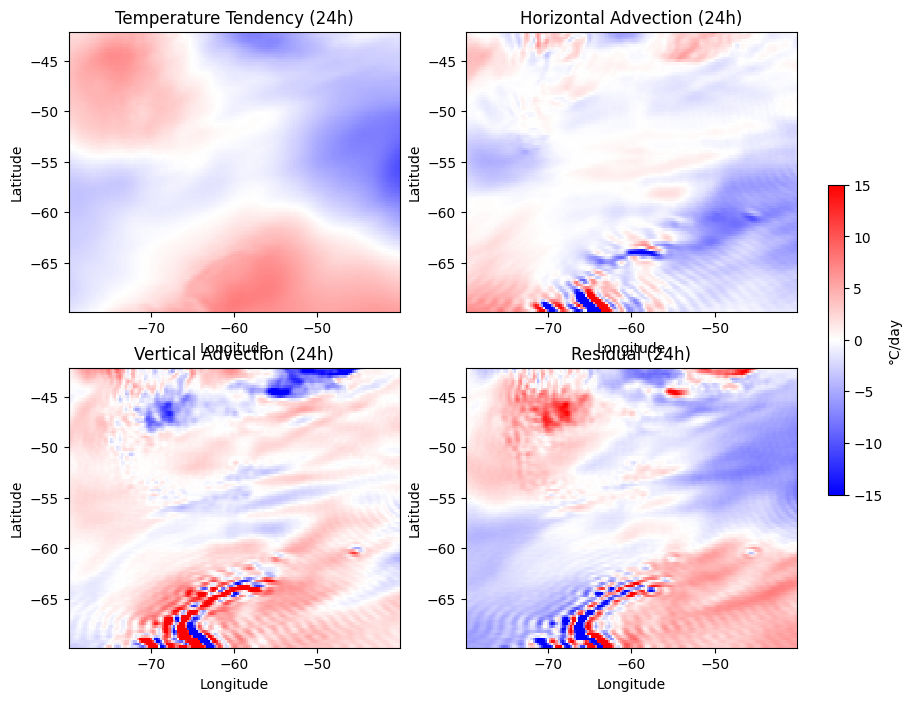

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ntime = 3
print(ds_out.time.values[ntime])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax = axes.flatten()

vmax = 15
vmin = -vmax

# --- Variables ---
vars_plot = ["tendency", "adv_h", "adv_v", "residual"]
titles = [
    "Temperature Tendency (24h)",
    "Horizontal Advection (24h)",
    "Vertical Advection (24h)",
    "Residual (24h)"
]

lon = ds_out.longitude.values
lat = ds_out.latitude.values

# Create meshgrid
lon2d, lat2d = np.meshgrid(lon, lat)

# --- Loop ---
for i, v in enumerate(vars_plot):

    im = ax[i].pcolormesh(
        lon2d,
        lat2d,
        ds_out[v].isel(time=ntime).values,
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )

    ax[i].set_title(titles[i])
    ax[i].set_xlabel("Longitude")
    ax[i].set_ylabel("Latitude")

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("°C/day")



2020-02-13T11:30:00


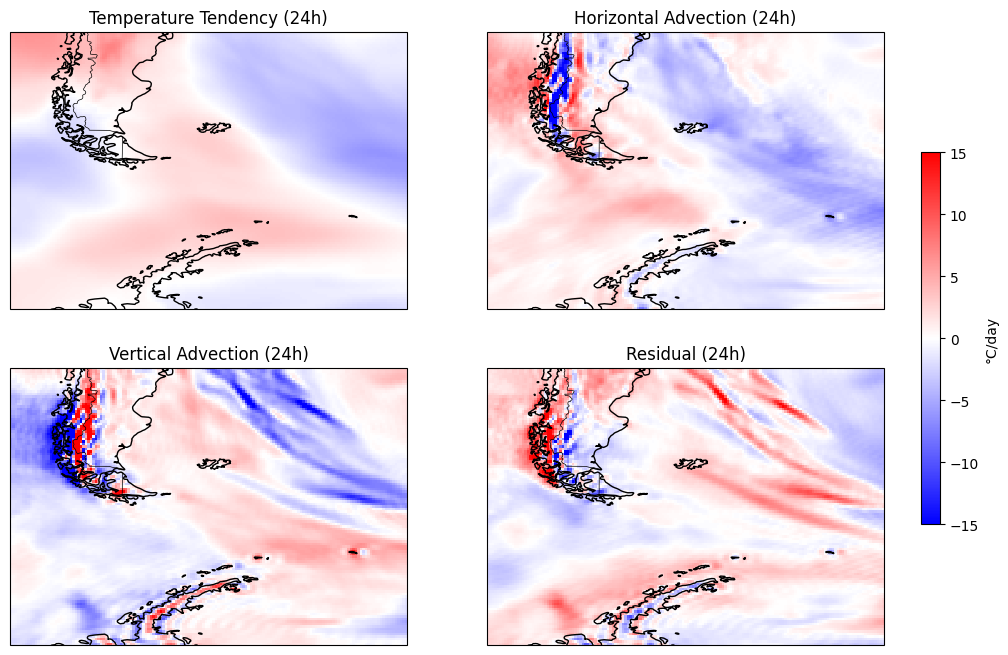

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})

ax = axes.flatten()
ntime = 9
print(dtimes[ntime])

# Recorta lats/lons igual que tus datos (1:-1)
lons_plot = lons[1:-1]
lats_plot = lats[1:-1]


# --- Escala simétrica ---
vmax = 15
vmin = -vmax

# --- Plot ---
data_list = [
    Tend_24H[ntime],
    Adv_24H[ntime],
    VAdv_24H[ntime],
    Res_24H[ntime]
]

titles = [
    'Temperature Tendency (24h)',
    'Horizontal Advection (24h)',
    'Vertical Advection (24h)',
    'Residual (24h)'
]

for i in range(4):
    im = ax[i].pcolormesh(lons_plot, lats_plot, data_list[i],
                          cmap='bwr', vmin=vmin, vmax=vmax,
                          transform=ccrs.PlateCarree())

    ax[i].set_title(titles[i])

    # Coastline
    ax[i].coastlines()

    # Opcional: bordes y grilla
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5)
    #ax[i].gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# --- Colorbar común ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('°C/day')


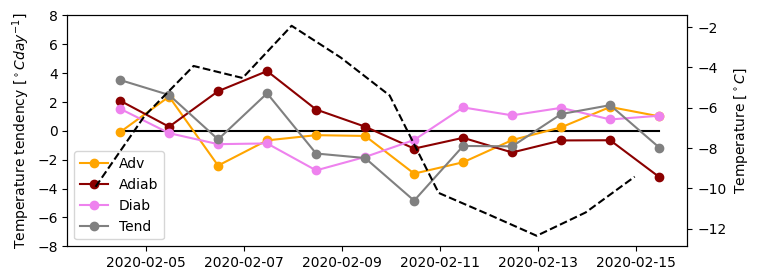

In [ ]:
#Get dimensions
lons = nc.variables['longitude'][:]
lats = nc.variables['latitude'][:]
times = nc.variables['valid_time'][:]

#Weighting grid
lons_sec_grid, lats_sec_grid = np.meshgrid(lons, lats)
weighting_grid = np.sqrt(np.cos(lats_sec_grid*np.pi/180))

lon2d, lat2d = np.meshgrid(lons, lats)

spatial_mask = (lat2d >= -70) & (lat2d <= -62) & \
               (lon2d >= -76) & (lon2d <= -55)

mask2d = spatial_mask[1:-1, 1:-1]
weights = weighting_grid[1:-1, 1:-1]

# aplicar máscara a pesos
weights_masked = np.where(mask2d, weights, 0)

starting_day_plot = '2020-02-04T00'
ending_day_plot = '2020-02-16T00'

Adv_Period  = np.sum(weights_masked * Adv_24H, axis=(1,2)) / np.sum(weights_masked)
VAdv_Period = np.sum(weights_masked * VAdv_24H, axis=(1,2)) / np.sum(weights_masked)
Res_Period  = np.sum(weights_masked * Res_24H, axis=(1,2)) / np.sum(weights_masked)
Tend_Period = np.sum(weights_masked * Tend_24H, axis=(1,2)) / np.sum(weights_masked)
T925_Period = np.sum(weights_masked * T925_24H, axis=(1,2))/np.sum(weights_masked)

mask = (dtimes >= np.datetime64(starting_day_plot)) & \
       (dtimes <= np.datetime64(ending_day_plot))

dtimes_Period = dtimes[mask]

Adv_Period_plot  = Adv_Period[mask]
VAdv_Period_plot = VAdv_Period[mask]
Res_Period_plot  = Res_Period[mask]
Tend_Period_plot = Tend_Period[mask]
T925_Period_plot = T925_Period[mask]

fig, (ax1)  = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0}, figsize=(8,3), facecolor='white')
ax2 = ax1.twinx()


dtimes_Period = dtimes[(dtimes >= np.datetime64(starting_day_plot)) & (dtimes <= np.datetime64(ending_day_plot))]

ax1.plot([dtimes_Period[0],dtimes_Period[-1]],[0,0], 'k-')

ax1.plot(dtimes_Period, Adv_Period_plot, 'o-', color='Orange', label='Adv')
ax1.plot(dtimes_Period, VAdv_Period_plot, 'o-', color='DarkRed', label='Adiab')
ax1.plot(dtimes_Period, Res_Period_plot, 'o-', color='Violet', label='Diab')
ax1.plot(dtimes_Period, Tend_Period_plot, 'o-', color='Gray', label='Tend')

ax2.plot(dtimes_Period-np.timedelta64(12, 'h'), T925_Period_plot, '--', color='k', label='T925')
ax1.set_ylim(-8,8)

ax1.set_ylabel('Temperature tendency [$^\circ C day^{-1}$]')
ax2.set_ylabel('Temperature [$^\circ C$]')
ax1.legend()

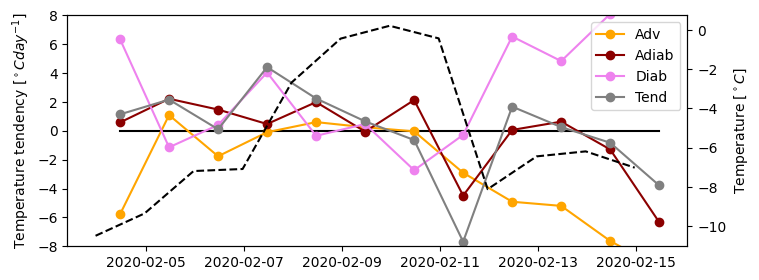

In [42]:
lon2d, lat2d = np.meshgrid(lons, lats)

spatial_mask = (lat2d >= -52.5) & (lat2d <= -45) & \
               (lon2d >= -74.5) & (lon2d <= -72)

mask2d = spatial_mask[1:-1, 1:-1]
weights = weighting_grid[1:-1, 1:-1]

# aplicar máscara a pesos
weights_masked = np.where(mask2d, weights, 0)

starting_day_plot = '2020-02-04T00'
ending_day_plot = '2020-02-16T00'

Adv_Period  = np.sum(weights_masked * Adv_24H, axis=(1,2)) / np.sum(weights_masked)
VAdv_Period = np.sum(weights_masked * VAdv_24H, axis=(1,2)) / np.sum(weights_masked)
Res_Period  = np.sum(weights_masked * Res_24H, axis=(1,2)) / np.sum(weights_masked)
Tend_Period = np.sum(weights_masked * Tend_24H, axis=(1,2)) / np.sum(weights_masked)
T925_Period = np.sum(weights_masked * T925_24H, axis=(1,2))/np.sum(weights_masked)

mask = (dtimes >= np.datetime64(starting_day_plot)) & \
       (dtimes <= np.datetime64(ending_day_plot))

dtimes_Period = dtimes[mask]

Adv_Period_plot  = Adv_Period[mask]
VAdv_Period_plot = VAdv_Period[mask]
Res_Period_plot  = Res_Period[mask]
Tend_Period_plot = Tend_Period[mask]
T925_Period_plot = T925_Period[mask]

fig, (ax1)  = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0}, figsize=(8,3), facecolor='white')
ax2 = ax1.twinx()


dtimes_Period = dtimes[(dtimes >= np.datetime64(starting_day_plot)) & (dtimes <= np.datetime64(ending_day_plot))]

ax1.plot([dtimes_Period[0],dtimes_Period[-1]],[0,0], 'k-')

ax1.plot(dtimes_Period, Adv_Period_plot, 'o-', color='Orange', label='Adv')
ax1.plot(dtimes_Period, VAdv_Period_plot, 'o-', color='DarkRed', label='Adiab')
ax1.plot(dtimes_Period, Res_Period_plot, 'o-', color='Violet', label='Diab')
ax1.plot(dtimes_Period, Tend_Period_plot, 'o-', color='Gray', label='Tend')
ax1.set_ylim(-8,8)

ax2.plot(dtimes_Period-np.timedelta64(12, 'h'), T925_Period_plot, '--', color='k', label='T925')

ax1.set_ylabel('Temperature tendency [$^\circ C day^{-1}$]')
ax2.set_ylabel('Temperature [$^\circ C$]')
ax1.legend()